In [2]:
import pandas as pd
import numpy as np

transactions = pd.read_csv("data/raw/train_transaction.csv")
identity = pd.read_csv("data/raw/train_identity.csv")

In [4]:
print("Transactions shape:", transactions.shape)
print("Identity shape:", identity.shape)
print("\nFraud rate:", transactions["isFraud"].mean())

Transactions shape: (590540, 394)
Identity shape: (144233, 41)

Fraud rate: 0.03499000914417313


In [6]:
transactions.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [10]:
# missing values
missing = transactions.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(20))

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V157     508595
V163     508595
V162     508595
V161     508595
V158     508595
V153     508595
V138     508595
V155     508595
V154     508595
V149     508595
V148     508595
V147     508595
dtype: int64


In [12]:
print(transactions.dtypes.value_counts())

float64    376
object      14
int64        4
Name: count, dtype: int64


In [14]:
# how many V features have less than 50% missing?
v_cols = [c for c in transactions.columns if c.startswith("V")]
v_missing = transactions[v_cols].isnull().mean()
print(f"V features with <50% missing: {(v_missing < 0.5).sum()}")
print(f"V features with >80% missing: {(v_missing > 0.8).sum()}")

V features with <50% missing: 180
V features with >80% missing: 47


In [16]:
# card columns distribution
for col in ["card4", "card6", "ProductCD"]:
    print(f"\n{col}:")
    print(transactions[col].value_counts())


card4:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

card6:
card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

ProductCD:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


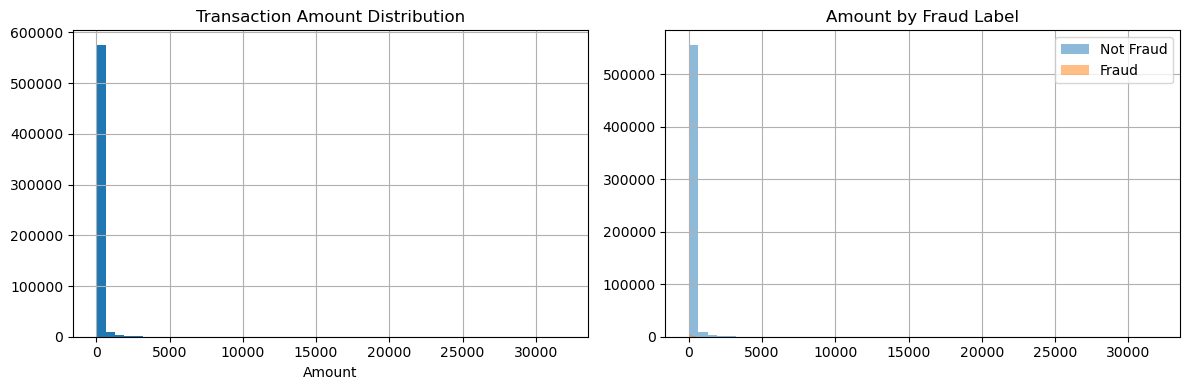

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# amount distribution
transactions["TransactionAmt"].hist(bins=50, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount")

# fraud vs non-fraud amounts
transactions.groupby("isFraud")["TransactionAmt"].hist(bins=50, alpha=0.5, ax=axes[1])
axes[1].set_title("Amount by Fraud Label")
axes[1].legend(["Not Fraud", "Fraud"])

plt.tight_layout()
plt.show()

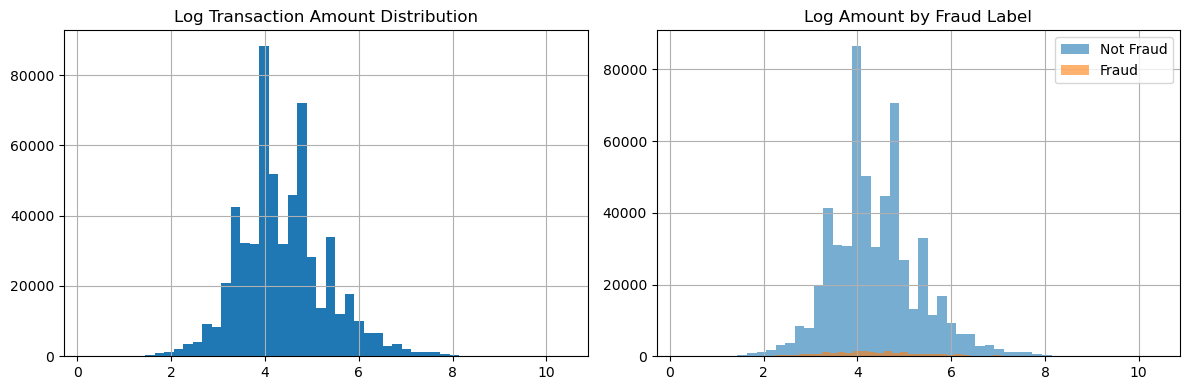

In [20]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# log transform amount
transactions["log_amt"] = np.log1p(transactions["TransactionAmt"])
transactions["log_amt"].hist(bins=50, ax=axes[0])
axes[0].set_title("Log Transaction Amount Distribution")

# fraud vs non-fraud on log scale
for fraud, group in transactions.groupby("isFraud"):
    group["log_amt"].hist(bins=50, alpha=0.6, ax=axes[1], 
                          label="Fraud" if fraud else "Not Fraud")
axes[1].set_title("Log Amount by Fraud Label")
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# fraud rate by product and card type
print("Fraud rate by ProductCD:")
print(transactions.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False))

print("\nFraud rate by card4:")
print(transactions.groupby("card4")["isFraud"].mean().sort_values(ascending=False))

print("\nFraud rate by card6:")
print(transactions.groupby("card6")["isFraud"].mean().sort_values(ascending=False))

Fraud rate by ProductCD:
ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64

Fraud rate by card4:
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64

Fraud rate by card6:
card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64


## EDA 

### Dataset
- 590K transactions, 394 features, 3.5% fraud rate — heavily imbalanced
- Identity file only covers ~24% of transactions — merge carefully with left join
- 376 float features, 14 categorical, 4 int

### Missing Values
- Drop V features with >80% missing (47 features gone)
- Keep V features with <50% missing (180 features)
- D columns (D6-D14) are mostly missing (handle/drop)

### Transaction Amount
- Heavily right-skewed — use log(TransactionAmt) as feature
- Fraud transactions don't differ dramatically in amount — amount alone won't catch fraud

### Strongest Features
- **ProductCD** — C has 11.7% fraud rate vs W at 2%. Biggest signal.
- **card6** — credit cards have 6.7% fraud vs debit at 2.4%
- **card4** — Discover has 7.7% fraud rate, highest of all networks
- These three categorical features should be top predictors

### Graph Design Decisions
- Transaction nodes — one per row, features = all engineered features
- Card nodes — built from card1 + card2 combination (unique card identifier)
- Edge = transaction connected to its card
(This will let the GNN see patterns like "this card made 10 transactions in 1 hour")

### Modeling Decisions
- Use log(TransactionAmt) not raw amount
- Encode ProductCD, card4, card6 as features
- Class imbalance — use weighted loss in GNN, scale_pos_weight in XGBoost
- Evaluate with AUC-ROC and Recall, not accuracy